# Examples of Deep BSDE Solver Applications 
In this notebook we reproduce the numerical examples of Han, Jentzen and E, *Solving high-dimensional partial differential equations using deep learning* (PNAS 2018, [1]), with the deep BSDE solver of this project.

![The three formulations of a parabolic terminal value problem and their numerical methods](figures/deep_bsde_route.png)

The objects involved:

- $X = (X_t)_{0 \le t \le T}$, the forward process, $$\mathrm{d}X_t = \mu(t, X_t)\,\mathrm{d}t + \sigma(t, X_t)\,\mathrm{d}W_t, \quad X_0 = x_0 \in \mathbb{R}^d.$$
- $u(t,x)$, the solution of the semilinear parabolic PDE $$\begin{align*}\;0 &= \partial_t u + \mu\cdot\nabla u + \tfrac12\operatorname{Tr}(\sigma\sigma' D^2 u) + f(t, x, u, \sigma'\nabla u) ,\\ u(T,\cdot) &= g. \end{align*}$$
- $Y_t = u(t, X_t)$, the value process, and $Z_t = \sigma'\nabla u(t, X_t)$, the control process.
- $\varphi_Z(t_n, \cdot\,|\,\theta_n)$, one network per time step for the control.
- $\Theta = (\widehat Y_0, Z_0, \theta_1, \dots, \theta_{N-1})$, the trainable parameters where $\widehat Y_0$ is the estimate of $u(0, x_0)$.

In [2]:
import sys, pathlib

SRC = pathlib.Path.cwd() / "source code"
sys.path.insert(0, str(SRC))

import math
from functools import partial
import numpy as np
import torch
import matplotlib.pyplot as plt

from bsde.solver import DeepBSDESolver
from NN_model.networks import FeedForwardNet
from plot_helpers import (plot_line, plot_relative_error, plot_value_comparison,
                          plot_y0_convergence)

FIGURES = pathlib.Path("figures").resolve()
FIGURES.mkdir(exist_ok=True)

RUNS = (1, 2, 3)      # independent runs per example (seeds)

## Example 1: Hamilton-Jacobi-Bellman equation
The stochastic optimal control problem
$$
\inf_{\{m_t\}_{t\in[0,T]}}\; \mathbb{E}\left[\int_0^T \lVert m_t\rVert^2\,\mathrm dt + g(X_T)\right],
\qquad \mathrm dX_t = 2\sqrt{\lambda}\, m_t\,\mathrm dt + \sqrt{2}\,\mathrm dW_t,
$$
with terminal cost $g(x) = \ln\left(\tfrac12\left(1+\lVert x\rVert^2\right)\right)$ reduces to the PDE
$$
\partial_t u + \Delta u - \lambda \lVert \nabla u\rVert^2 = 0, \qquad u(T,x) = g(x).
$$
for the value function 
$$u(t,x) := \inf_{\{m_t\}_{t\in[0,T]}}\; \mathbb E\left[\int_t^T \lVert m_s\rVert^2\mathrm ds + g(X_T)\Big| X_t = x\right].$$
In the solver's variables the forward process is $\mathrm{d}X_t = \sqrt2\,\mathrm{d}W_t$, so $z = \sqrt2\,\nabla u$ and the driver reads $f(z) = -\tfrac{\lambda}{2}\lVert z\rVert^2$.

We first set up an HJB equation by defining a class with the necessary model functions.

In [ ]:
class HJBLQ:

    def __init__(self, d=100, T=1.0, lam=1.0):
        self.d = d
        self.m = 1
        self.T = T
        self.lam = lam
        self.x0 = torch.zeros(d)
        self._sqrt2 = float(np.sqrt(2.0)) # precompute

    def drift(self, t, X):
        return None

    def diffusion_dW(self, t, X, dW):
        return self._sqrt2 * dW

    def normalize(self, X):
        return X

    def f(self, t, X, Y, Z):
        return -0.5 * self.lam * (Z ** 2).sum(dim=-1)

    def terminal(self, X):
        return torch.log(0.5 * (1.0 + (X ** 2).sum(dim=1, keepdim=True)))

As a benchmark, we use the Feynman-Kac representation

$$
u(0,x_0)
=-\frac{1}{\lambda}
\log \mathbb{E}\left[
\exp\left(
-\lambda g\left(x_0+\sqrt{2},W_T\right)
\right)
\right].
$$

We approximate it by the Monte Carlo estimator

$$
\widehat{u}_M(0,x_0)
=-\frac{1}{\lambda}
\log\left(
\frac{1}{M}\sum_{m=1}^M
\exp\left[
-\lambda g\left(x_0+\sqrt{2},W_T^{(m)}\right)
\right]
\right).
$$
We run it multiple times to also estimate the confidence area around the curve.

In [ ]:
LAMBDAS = (1, 10, 20, 30, 40, 50)
rng = np.random.default_rng(0)
g_samples = np.concatenate(
    [np.log(0.5 * (1 + 2 * (rng.standard_normal((100_000, 100)) ** 2).sum(axis=1)))
     for _ in range(20)])
reference_mc = {lam: -np.log(np.exp(-lam * g_samples).mean()) / lam for lam in LAMBDAS}
y0_uncontrolled = g_samples.mean() 
for lam in LAMBDAS:
    print(f"lambda = {lam:2d}, Monte Carlo Estimate = {reference_mc[lam]:.4f}")
reference_exact = reference_mc   # the log-MC value serves as the exact reference


uncontrolled value E[g(X_T)] = 4.6004
lambda =  1: exact = 4.5902, Monte Carlo = 4.5903
lambda = 10: exact = 4.4929, Monte Carlo = 4.4931
lambda = 20: exact = 4.3671, Monte Carlo = 4.3736
lambda = 30: exact = 4.2136, Monte Carlo = 4.2659
lambda = 40: exact = 4.0131, Monte Carlo = 4.1884
lambda = 50: exact = 3.7242, Monte Carlo = 4.1347


In [4]:
hjb_values = []                                     # Y_0 per iteration, one row per run
for run in RUNS:
    solver = DeepBSDESolver(HJBLQ(), net=FeedForwardNet, N=20, hidden=110, seed=run,
                            y0_init=y0_uncontrolled, z_init_scale=0.1)
    solver.solve(num_iter=2500, batch=128, lr=3e-3, lr_end=3e-4)
    hjb_values.append(solver.y0_history)
    print(f"lambda = 1, run {run}: value = {solver.value:.4f}")
hjb_values = np.array(hjb_values)

training:   0%|          | 0/2500 [00:00<?, ? iter/s]

lambda = 1, run 1: value = 4.5915


training:   0%|          | 0/2500 [00:00<?, ? iter/s]

lambda = 1, run 2: value = 4.5893


training:   0%|          | 0/2500 [00:00<?, ? iter/s]

lambda = 1, run 3: value = 4.5908


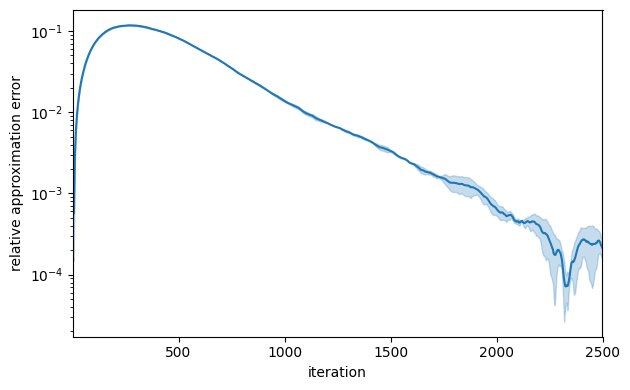

In [18]:
iterations = np.arange(1, hjb_values.shape[1] + 1)
errors = np.abs(hjb_values - reference_exact[1]) / reference_exact[1]
plot_relative_error(iterations, errors, save=FIGURES / "deep_bsde_pnas_hjb_error.png");

In [5]:
hjb_sweep = {}
for lam in LAMBDAS:
    solver = DeepBSDESolver(HJBLQ(lam=float(lam)), net=FeedForwardNet, N=20, hidden=110,
                            seed=1, y0_init=y0_uncontrolled, z_init_scale=0.1)
    solver.solve(num_iter=2500, batch=128, lr=3e-3, lr_end=3e-4)
    hjb_sweep[lam] = solver.value
    print(f"lambda = {lam:2d}: value = {solver.value:.4f} (exact {reference_exact[lam]:.4f})")

training:   0%|          | 0/2500 [00:00<?, ? iter/s]

lambda =  1: value = 4.5915 (exact 4.5902)


training:   0%|          | 0/2500 [00:00<?, ? iter/s]

lambda = 10: value = 4.5065 (exact 4.4929)


training:   0%|          | 0/2500 [00:00<?, ? iter/s]

...

lambda = 30: value = 4.2585 (exact 4.2136)


training:   0%|          | 0/2500 [00:00<?, ? iter/s]

lambda = 40: value = 4.2124 (exact 4.0131)


training:   0%|          | 0/2500 [00:00<?, ? iter/s]

lambda = 50: value = 4.1844 (exact 3.7242)


The relative error of the three $\lambda = 1$ runs against the exact reference over the iterations, and the trained values across the $\lambda$ sweep against both references.

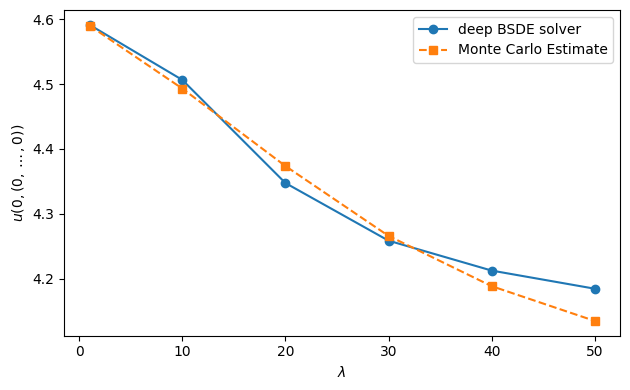

lambda = 1: value = 4.5905, relative error 0.01% (paper 0.17%)


In [ ]:
plot_value_comparison(LAMBDAS,
                      {"deep BSDE solver": [hjb_sweep[lam] for lam in LAMBDAS],
                       "Monte Carlo Estimate": [reference_mc[lam] for lam in LAMBDAS]},
                      xlabel=r"$\lambda$", ylabel=r"$u(0,(0,\dots,0))$",
                      save=FIGURES / "deep_bsde_pnas_hjb_lambda.png")
final = hjb_values[:, -1].mean()
print(f"lambda = 1: value = {final:.4f}, relative error {abs(final - reference_exact[1]) / reference_exact[1] * 100:.2f}% (paper 0.17%)")

At $\lambda = 1$ the solver reproduces the reference value at an even higher accurancy than postulated in the paper.

As a stability test we repeat the training of the $\lambda = 1$ equation from different starting values of the trainable initial value $\widehat Y_0$.

In [ ]:
# stability test: identical training from different starting values of Y0
def plot_init_stability(histories, inits, reference, ylabel, name):
    iterations = np.arange(1, histories.shape[1] + 1)
    fig, ax = plt.subplots(figsize=(6.4, 4))
    for y0, h in zip(inits, histories):
        ax.plot(iterations, h, lw=1.0, label=f"$\\widehat Y_0$ init ${y0:g}$")
    ax.axhline(reference, color="black", ls="--", lw=1.0, label="reference")
    ax.set_xlabel("iteration")
    ax.set_ylabel(ylabel)
    ax.margins(x=0)
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURES / f"deep_bsde_pnas_{name}_init_stability.png",
                dpi=200, bbox_inches="tight")
    plt.show()
    return fig

hjb_inits = (0.0, 2.0, 6.0, 10.0)
hjb_stab = []
for y0 in hjb_inits:
    solver = DeepBSDESolver(HJBLQ(), net=FeedForwardNet, N=20, hidden=110, seed=1,
                            y0_init=y0, z_init_scale=0.1)
    solver.solve(num_iter=1500, batch=128, lr=3e-3, lr_end=3e-4)
    hjb_stab.append(solver.y0_history)
    print(f"y0_init = {y0:5.1f}: value = {solver.value:.4f}")
plot_init_stability(np.array(hjb_stab), hjb_inits, reference_exact[1],
                    r"$u(0,(0,\dots,0))$", "hjb");

The distance between the final levels of the curves measures how sensitive the trained value is to the initialization.

## Example 2: Allen-Cahn equation
The time reversal $v(t,x) = u(T-t,x)$ turns the Allen-Cahn equation
$$
\partial_t u = \Delta u + u - u^3, \qquad u(0,x) = g(x) = \frac{1}{2 + 0.4\,\lVert x\rVert^2},
$$
into a terminal value problem with $\sigma = \sqrt2\, I$ and the driver $f(y) = y - y^3$, so training with horizon $T$ returns $u(T,(0,\dots,0))$. As a benchmark we use $u(0.3,(0,\dots,0)) \approx 0.0528$.

In [ ]:
class AllenCahn:
    
    def __init__(self, d=100, T=0.3):
        self.d, self.m, self.T = d, 1, T
        self.x0 = torch.zeros(d)
        self._sqrt2 = float(np.sqrt(2.0))

    def drift(self, t, X):
        return None

    def diffusion_dW(self, t, X, dW):
        return self._sqrt2 * dW

    def normalize(self, X):
        return X

    def f(self, t, X, Y, Z):
        Yc = torch.clamp(Y, -2.0, 2.0)     # clamp keeps training finite
        return Yc - Yc ** 3

    def terminal(self, X):
        return 1.0 / (2.0 + 0.4 * (X ** 2).sum(dim=1, keepdim=True))

We perform three runs at $T = 0.3$ to replicate the confidence area as well.

In [ ]:
AC_REFERENCE = 0.0528
allen_cahn_values = []
for run in RUNS:
    solver = DeepBSDESolver(AllenCahn(), net=FeedForwardNet, N=20, hidden=110, seed=run, z_init_scale=0.1)
    solver.solve(num_iter=4000, batch=64, lr=1e-3, lr_end=1e-4, net_lr_scale=0.1)
    allen_cahn_values.append(solver.y0_history)
    print(f"T = 0.3, run {run}: value = {solver.value:.4f}")
allen_cahn_values = np.array(allen_cahn_values)

training:   0%|          | 0/4000 [00:00<?, ? iter/s]

T = 0.3, run 1: value = 0.0528


training:   0%|          | 0/4000 [00:00<?, ? iter/s]

T = 0.3, run 2: value = 0.0527


training:   0%|          | 0/4000 [00:00<?, ? iter/s]

T = 0.3, run 3: value = 0.0530


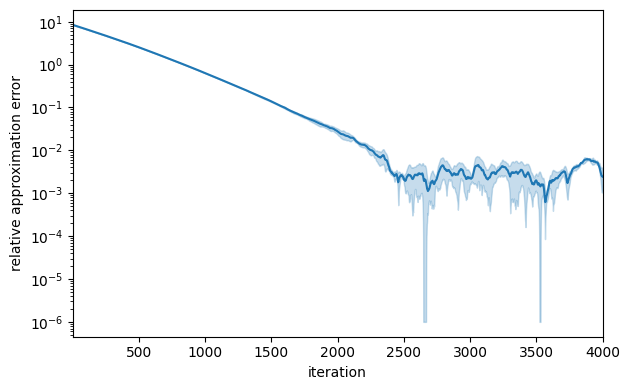

value = 0.0528 (reference 0.0528), relative error 0.02% (paper 0.30%)


In [28]:
iterations = np.arange(1, allen_cahn_values.shape[1] + 1)
errors = np.abs(allen_cahn_values - AC_REFERENCE) / AC_REFERENCE
plot_relative_error(iterations, errors, save=FIGURES / "deep_bsde_pnas_allencahn_error.png")
final = allen_cahn_values[:, -1].mean()
print(f"value = {final:.4f} (reference {AC_REFERENCE}), relative error {abs(final - AC_REFERENCE) / AC_REFERENCE * 100:.2f}% (paper 0.30%)")

Next, one run per horizon for the time evolution $t \mapsto u(t,(0,\dots,0))$ is performed.

In [10]:
T_GRID = (0.02, 0.05, 0.08, 0.11, 0.14, 0.18, 0.22, 0.26, 0.30)

evolution = []
for T in T_GRID:
    solver = DeepBSDESolver(AllenCahn(T=T), net=FeedForwardNet, N=20, hidden=110, seed=1,
                            z_init_scale=0.1)
    solver.solve(num_iter=3000, batch=64, lr=1e-3, lr_end=1e-4, net_lr_scale=0.1)
    evolution.append(solver.value)
    print(f"T = {T:.2f}: value = {solver.value:.4f}")

training:   0%|          | 0/3000 [00:00<?, ? iter/s]

T = 0.02: value = 0.2841


training:   0%|          | 0/3000 [00:00<?, ? iter/s]

T = 0.05: value = 0.1766


training:   0%|          | 0/3000 [00:00<?, ? iter/s]

...

T = 0.22: value = 0.0649


training:   0%|          | 0/3000 [00:00<?, ? iter/s]

T = 0.26: value = 0.0583


training:   0%|          | 0/3000 [00:00<?, ? iter/s]

T = 0.30: value = 0.0534


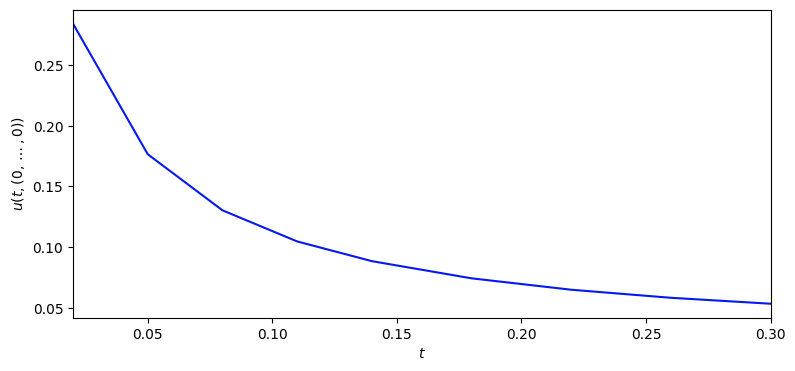

In [30]:
plot_line(T_GRID, evolution, xlabel="$t$", ylabel=r"$u(t,(0,\dots,0))$",
          save=FIGURES / "deep_bsde_pnas_allencahn_time.png");

The plots deliver comparable results.

The same stability test for the Allen-Cahn equation, the training is started from four different values of $\widehat Y_0$.

In [ ]:
# stability test for the Allen-Cahn equation
ac_inits = (-1.0, 0.0, 0.3, 1.0)
ac_stab = []
for y0 in ac_inits:
    solver = DeepBSDESolver(AllenCahn(), net=FeedForwardNet, N=20, hidden=110, seed=1,
                            y0_init=y0, z_init_scale=0.1)
    solver.solve(num_iter=2000, batch=64, lr=1e-3, lr_end=1e-4, net_lr_scale=0.1)
    ac_stab.append(solver.y0_history)
    print(f"y0_init = {y0:5.1f}: value = {solver.value:.4f}")
plot_init_stability(np.array(ac_stab), ac_inits, AC_REFERENCE,
                    r"$u(0.3,(0,\dots,0))$", "allencahn");

Since the reference value is small, the plot shows directly whether remote starting values find their way back to it.

## Example 3: Nonlinear Black-Scholes equation with default risk
We set $T=1$, $\bar\mu = 0.02$, $\bar\sigma = 0.2$, $\delta = 2/3$, $R = 0.02$, $v^h = 50$, $v^l = 70$, $\gamma^h = 0.2$, $\gamma^l = 0.02$ and consider the Black-Scholes PDE
$$
0 = \partial_t u + \bar\mu\, x\cdot\nabla u + \frac{\bar\sigma^2}{2}\sum_{i=1}^{100} x_i^2\,\frac{\partial^2 u}{\partial x_i^2} + f(u),
\qquad u(T,x) = \min(x_1,\dots,x_{100}),
$$
with driver
$$
f(y) = -(1-\delta)\,Q(y)\,y - R\,y, \qquad
$$
where $Q$ is given by
$$
Q(y) = \gamma^h \mathbf{1}_{(-\infty,v^h)}(y)
+ \gamma^l \mathbf{1}_{[v^l,\infty)}(y)
+ \mathbf{1}_{[v^h,v^l)}(y)\left[\frac{\gamma^h-\gamma^l}{v^h-v^l}\left(y-v^h\right)+\gamma^h.\right]
$$
As a benchmark we use $u(0,(100,\dots,100)) \approx 57.300$. Following the paper's `y_init_range` of $[40, 50]$ we start the trainable initial value at $50$.

We first take a look at the function $Q$.

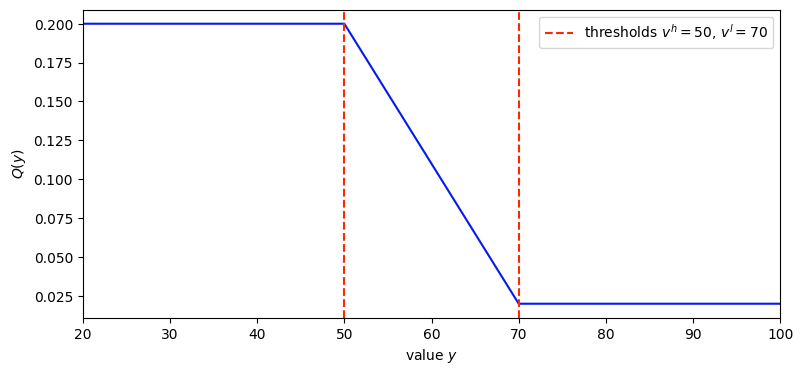

In [8]:
value_grid = np.linspace(20.0, 100.0, 401)
intensity_grid = np.clip((0.2 - 0.02) / (50.0 - 70.0) * (value_grid - 50.0) + 0.2, 0.02, 0.2)
plot_line(value_grid, intensity_grid, xlabel="value $y$", ylabel="$Q(y)$",
          vline=[50.0, 70.0], vline_label="thresholds $v^h = 50$, $v^l = 70$",
          save=FIGURES / "deep_bsde_pnas_default_intensity.png");

$Q$ can be interpreted as a threshold into a region of high, medium and low risk of default.

In [32]:
class PricingDefaultRisk:

    def __init__(self, d=100, T=1.0, mu=0.02, sigma=0.2, delta=2.0 / 3.0, R=0.02,
                 gamma_h=0.2, gamma_l=0.02, v_h=50.0, v_l=70.0):
        self.d, self.m, self.T = d, 1, T
        self.x0 = torch.full((d,), 100.0)
        self.mu, self.sigma, self.delta, self.R = mu, sigma, delta, R
        self.gamma_h, self.gamma_l, self.v_h, self.v_l = gamma_h, gamma_l, v_h, v_l
        self._slope = (gamma_h - gamma_l) / (v_h - v_l)

    def drift(self, t, X):
        return self.mu * X

    def diffusion_dW(self, t, X, dW):
        return self.sigma * X * dW

    def normalize(self, X):
        return X / 100.0 - 1.0

    def f(self, t, X, Y, Z):
        Q = torch.clamp(self._slope * (Y - self.v_h) + self.gamma_h,
                        min=self.gamma_l, max=self.gamma_h)
        return -(1.0 - self.delta) * Q * Y - self.R * Y

    def terminal(self, X):
        return X.min(dim=1, keepdim=True).values

In [ ]:
DR_REFERENCE = 57.300

default_risk_values = []  # Y_0 per iteration, one row per run
for run in RUNS:
    solver = DeepBSDESolver(PricingDefaultRisk(), net=FeedForwardNet, N=40, hidden=110,
                            seed=run, y0_init=50.0, z_init_scale=0.1)
    solver.solve(num_iter=4000, batch=64, lr=1e-2, lr_end=1e-3)
    default_risk_values.append(solver.y0_history)
    print(f"run {run}: value = {solver.value:.4f}")
default_risk_values = np.array(default_risk_values)

training:   0%|          | 0/4000 [00:00<?, ? iter/s]

run 1: value = 57.0312


training:   0%|          | 0/4000 [00:00<?, ? iter/s]

run 2: value = 57.0413


training:   0%|          | 0/4000 [00:00<?, ? iter/s]

run 3: value = 57.0545


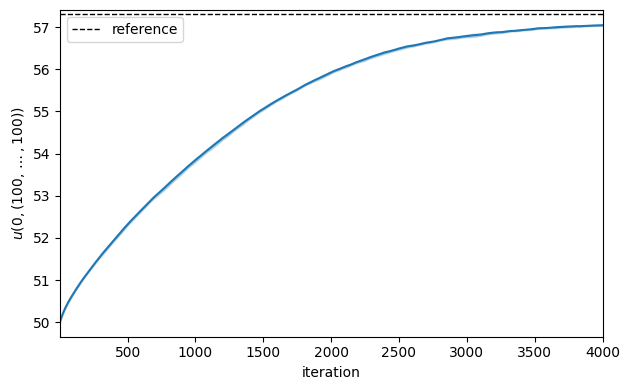

value = 57.042 (reference 57.3), relative error 0.45% (paper 0.46%)


In [ ]:
iterations = np.arange(1, default_risk_values.shape[1] + 1)
plot_y0_convergence(iterations, default_risk_values, reference=DR_REFERENCE,
                    ylabel=r"$u(0,(100,\dots,100))$",
                    save=FIGURES / "deep_bsde_pnas_default_risk_y0.png")
final = default_risk_values[:, -1].mean()
print(f"value = {final:.3f} (reference {DR_REFERENCE}), relative error {abs(final - DR_REFERENCE) / DR_REFERENCE * 100:.2f}% (paper 0.46%)")

Comparing with the result in the paper, also here we get a similar result.

For the default risk equation the starting value selects a risk regime of $Q$, so we start the training below, inside and above the threshold region.

In [ ]:
# stability test for the default risk equation, starting values below,
# inside and above the threshold region of Q
dr_inits = (20.0, 40.0, 60.0, 90.0)
dr_stab = []
for y0 in dr_inits:
    solver = DeepBSDESolver(PricingDefaultRisk(), net=FeedForwardNet, N=40, hidden=110,
                            seed=1, y0_init=y0, z_init_scale=0.1)
    solver.solve(num_iter=2000, batch=64, lr=1e-2, lr_end=1e-3)
    dr_stab.append(solver.y0_history)
    print(f"y0_init = {y0:5.1f}: value = {solver.value:.4f}")
plot_init_stability(np.array(dr_stab), dr_inits, DR_REFERENCE,
                    r"$u(0,(100,\dots,100))$", "default_risk");

A gap between the final levels would indicate that the nonlinearity traps the training in the regime of its starting value.

## Example 4: Reaction-diffusion equation and network depth

We consider the PDE
$$
\partial_t u+\frac12\Delta u+\min\big\{1\ (u-u^*)^2\big\}=0, \quad u(T\ x)=u^*(T\ x)
$$
which is as reaction-diffusion equation. One can show that the solution satisfies
$$
u^*(t\ x)
=1+\kappa
+
\sin\left(\lambda\sum_{i=1}^d x_i\right)
\exp\left(\frac{\lambda^2d(t-T)}{2}\right)
$$
If we choose $\kappa=0.6, \lambda=\frac1{\sqrt d}, T=1, d=100, N=30, we get the benchmar $$u(0\ 0)=1+\kappa=1.6$$

In [ ]:
class ReactionDiffusion:

    def __init__(self, d=100, T=1.0, kappa=0.6):
        self.d, self.m, self.T, self.kappa = d, 1, T, kappa
        self.lam = 1.0 / np.sqrt(d)
        self.x0 = torch.zeros(d)

    def drift(self, t, X):
        return None

    def diffusion_dW(self, t, X, dW):
        return dW

    def normalize(self, X):
        return X

    def _u_star(self, t, X):
        return 1.0 + self.kappa + torch.sin(self.lam * X.sum(dim=1, keepdim=True)) \
            * np.exp(0.5 * self.lam ** 2 * self.d * (t - self.T))

    def f(self, t, X, Y, Z):
        return torch.clamp((Y - self._u_star(t, X)) ** 2, max=1.0)

    def terminal(self, X):
        return self._u_star(self.T, X)

In [16]:
RD_EXACT = 1.6
RD_ITERS = 40000          # training steps per run
DEPTHS = (1, 2, 3, 4)
PAPER_TABLE1 = {1: 0.90, 2: 0.60, 3: 0.56, 4: 0.53}

mean_errors, sd_errors = [], []
print(f"{'hidden layers':<14} {'mean rel. error':>16} {'SD':>8} {'paper mean':>11}")
for depth in DEPTHS:
    finals = []
    for run in RUNS:
        solver = DeepBSDESolver(ReactionDiffusion(), net=partial(FeedForwardNet, depth=depth),
                                N=30, hidden=110, seed=run, y0_init=0.5, z_init_scale=0.1)
        solver.solve(num_iter=RD_ITERS, batch=64, lr=1e-2, lr_end=3e-4, net_lr_scale=0.1)
        finals.append(solver.value)
    rel = np.abs(np.array(finals) - RD_EXACT) / RD_EXACT * 100
    mean_errors.append(rel.mean())
    sd_errors.append(rel.std())
    print(f"{depth:<14} {rel.mean():>15.2f}% {rel.std():>7.2f}% {PAPER_TABLE1[depth]:>10.2f}%")

hidden layers   mean rel. error       SD  paper mean


training:   0%|          | 0/4000 [00:00<?, ? iter/s]

training:   0%|          | 0/4000 [00:00<?, ? iter/s]

training:   0%|          | 0/4000 [00:00<?, ? iter/s]

1                        17.41%    0.06%       0.90%


...

3                         3.40%    0.09%       0.56%


training:   0%|          | 0/4000 [00:00<?, ? iter/s]

training:   0%|          | 0/4000 [00:00<?, ? iter/s]

training:   0%|          | 0/4000 [00:00<?, ? iter/s]

4                         2.80%    0.02%       0.53%


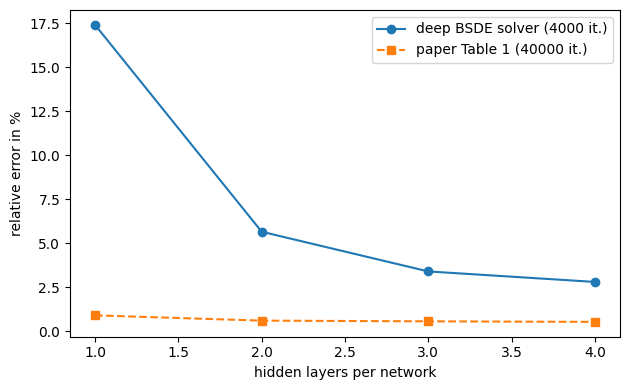

In [17]:
plot_value_comparison(DEPTHS,
                      {f"deep BSDE solver ({RD_ITERS} it.)": mean_errors,
                       "paper Table 1 (40000 it.)": [PAPER_TABLE1[d] for d in DEPTHS]},
                      xlabel="hidden layers per network", ylabel="relative error in %",
                      save=FIGURES / "deep_bsde_pnas_layers.png");

Qualitatively, one can see, that the error is greatly decreased by the increase in layers. In the paper, 40.000 training steps where used, so we have expectetly worse relative errors. Due to the computational effort we will close this example with a qualitative confirmation only.

The reaction-diffusion equation is trained from starting values below, at and above the benchmark $u(0,0) = 1.6$.

In [ ]:
# stability test for the reaction-diffusion equation
rd_inits = (0.0, 0.5, 1.6, 3.0)
rd_stab = []
for y0 in rd_inits:
    solver = DeepBSDESolver(ReactionDiffusion(), net=FeedForwardNet, N=30, hidden=110,
                            seed=1, y0_init=y0, z_init_scale=0.1)
    solver.solve(num_iter=2000, batch=64, lr=1e-2, lr_end=3e-4, net_lr_scale=0.1)
    rd_stab.append(solver.y0_history)
    print(f"y0_init = {y0:5.1f}: value = {solver.value:.4f}")
plot_init_stability(np.array(rd_stab), rd_inits, RD_EXACT,
                    r"$u(0,(0,\dots,0))$", "reaction_diffusion");

The clamped driver keeps all runs finite, so the comparison isolates the effect of the initialization alone.

## References

[1] Han, J., Jentzen, A. and E, W. (2018). Solving high-dimensional partial differential equations using deep learning. *PNAS*, 115(34):8505-8510. [https://doi.org/10.1073/pnas.1718942115](https://doi.org/10.1073/pnas.1718942115)

[2] E, W., Han, J. and Jentzen, A. (2017). Deep learning-based numerical methods for high-dimensional parabolic partial differential equations and backward stochastic differential equations. *Communications in Mathematics and Statistics*, 5(4):349-380. [https://doi.org/10.1007/s40304-017-0117-6](https://doi.org/10.1007/s40304-017-0117-6)